In [1]:
import numpy as np 
import pandas as pd


In [2]:
# random seed
np.random.seed(42) # to obtain consistent  random numbers

set1no = 900
set2no = 100


In [4]:
df1 = pd.DataFrame({"feature_1": np.random.normal(loc=0,scale=1,size = set1no),
                    "feature_2": np.random.normal(loc=0,scale=1,size=set1no),
                   "target": [0]*set1no})
df2 = pd.DataFrame({"feature_1": np.random.normal(loc=0,scale=1,size = set2no),
                    "feature_2": np.random.normal(loc=0,scale=1,size=set2no),
                   "target": [1]*set2no})

In [5]:
df1.head()

,feature_1,feature_2,target
0,1.399355,0.696954,0
1,0.924634,-0.333819,0
2,0.059630,1.173125,0
3,-0.646937,0.369642,0
4,0.698223,-0.107302,0


In [6]:
df2.head()

,feature_1,feature_2,target
0,0.183835,-0.045512,1
1,2.693034,-0.424236,1
2,0.349800,-0.569833,1
3,-1.004055,0.329509,1
4,-0.095464,-1.517174,1


In [7]:
df = pd.concat([df1,df2]).reset_index(drop = True)

In [8]:
df

,feature_1,feature_2,target
0,1.399355,0.696954,0
1,0.924634,-0.333819,0
2,0.059630,1.173125,0
3,-0.646937,0.369642,0
4,0.698223,-0.107302,0
...,...,...,...
995,3.926238,0.077481,1
996,-2.084113,0.257753,1
997,1.724697,-1.241761,1
998,-0.287448,0.334176,1


In [9]:
df["target"].unique()

array([0, 1])

In [10]:
df.target.value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [11]:
# if we want to train our model truely we can use  two method
# upsampling -> upsample minority
# downsampling -> downsample majority 


In [12]:
# if data amount is less then we should not down sampling

In [13]:
# upsampling

In [14]:
df_minority = df[ df["target"] == 1]

In [15]:
df_minority

,feature_1,feature_2,target
900,0.183835,-0.045512,1
901,2.693034,-0.424236,1
902,0.349800,-0.569833,1
903,-1.004055,0.329509,1
904,-0.095464,-1.517174,1
...,...,...,...
995,3.926238,0.077481,1
996,-2.084113,0.257753,1
997,1.724697,-1.241761,1
998,-0.287448,0.334176,1


In [16]:
df_majority = df[df["target"] == 0]

In [17]:
df_majority

,feature_1,feature_2,target
0,1.399355,0.696954,0
1,0.924634,-0.333819,0
2,0.059630,1.173125,0
3,-0.646937,0.369642,0
4,0.698223,-0.107302,0
...,...,...,...
895,-0.370011,-0.848429,0
896,-0.258796,0.573128,0
897,1.598647,-1.785866,0
898,0.560919,-0.359630,0


In [18]:
from sklearn.utils import resample 

In [21]:
df_minority_upsampled = resample(df_minority, replace = True , n_samples = len(df_majority), random_state = 42 )

In [23]:
df_minority_upsampled.shape

(900, 3)

In [24]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,0.833334,0.777407,1
992,0.768207,0.072037,1
914,1.832557,0.685508,1
971,0.458387,-0.068634,1
960,-0.531214,-0.824514,1


In [25]:
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

In [26]:
df_upsampled

,feature_1,feature_2,target
0,1.399355,0.696954,0
1,0.924634,-0.333819,0
2,0.059630,1.173125,0
3,-0.646937,0.369642,0
4,0.698223,-0.107302,0
...,...,...,...
952,-1.104863,0.466671,1
965,-0.307808,-0.258854,1
976,-0.936506,1.263707,1
942,1.476934,0.640480,1


In [27]:
df_upsampled["target"].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [28]:
df_majority_downsampled = resample(df_majority, replace = True , n_samples = len(df_minority), random_state = 42 )

In [29]:
df_majority_downsampled["target"].value_counts()

target
0    100
Name: count, dtype: int64

In [30]:
df_downsampled = pd.concat([df_majority_downsampled,df_minority])

In [31]:
df_downsampled

,feature_1,feature_2,target
102,2.088375,-0.792420,0
435,0.282580,0.575205,0
860,-0.134309,0.629530,0
270,1.091310,0.987335,0
106,0.612774,0.001205,0
...,...,...,...
995,3.926238,0.077481,1
996,-2.084113,0.257753,1
997,1.724697,-1.241761,1
998,-0.287448,0.334176,1


In [33]:
df_downsampled["target"].value_counts()

target
0    100
1    100
Name: count, dtype: int64

In [34]:
# up sample might be harmful since it is like copy pasting but instead we can use another algorithm that give similars not exactly same things 

In [35]:
# SMOTE (Syntetich Minority Over-sampling Technique)

In [36]:
df

,feature_1,feature_2,target
0,1.399355,0.696954,0
1,0.924634,-0.333819,0
2,0.059630,1.173125,0
3,-0.646937,0.369642,0
4,0.698223,-0.107302,0
...,...,...,...
995,3.926238,0.077481,1
996,-2.084113,0.257753,1
997,1.724697,-1.241761,1
998,-0.287448,0.334176,1


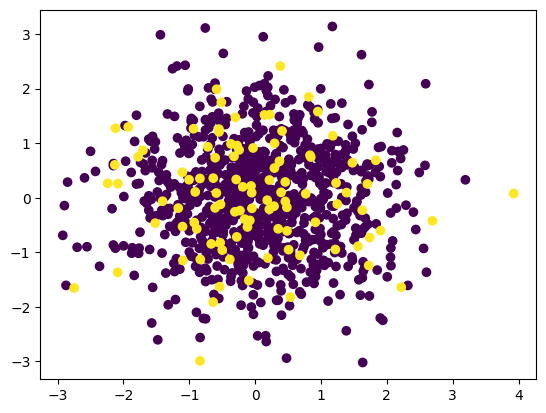

In [40]:
import matplotlib.pyplot as plt
plt.scatter(df["feature_1"], df["feature_2"], c = df["target"]) # c is like hue 

In [43]:
# imbalanced learn to apply smote

In [42]:
!pip install imblearn 

In [44]:
from imblearn.over_sampling import SMOTE

In [45]:
oversample = SMOTE()

In [47]:
(X,y) = oversample.fit_resample(df[["feature_1","feature_2"]], df["target"])  # y --> target , X --> feature

In [48]:
X

,feature_1,feature_2
0,1.399355,0.696954
1,0.924634,-0.333819
2,0.059630,1.173125
3,-0.646937,0.369642
4,0.698223,-0.107302
...,...,...
1795,1.603569,0.656514
1796,-0.834400,-1.724895
1797,-0.750315,-1.046310
1798,-0.843608,0.066384


In [49]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1795    1
1796    1
1797    1
1798    1
1799    1
Name: target, Length: 1800, dtype: int64

In [50]:
type(X)

pandas.DataFrame

In [51]:
oversample_df = pd.concat([X,y],axis = 1)

In [52]:
oversample_df

,feature_1,feature_2,target
0,1.399355,0.696954,0
1,0.924634,-0.333819,0
2,0.059630,1.173125,0
3,-0.646937,0.369642,0
4,0.698223,-0.107302,0
...,...,...,...
1795,1.603569,0.656514,1
1796,-0.834400,-1.724895,1
1797,-0.750315,-1.046310,1
1798,-0.843608,0.066384,1


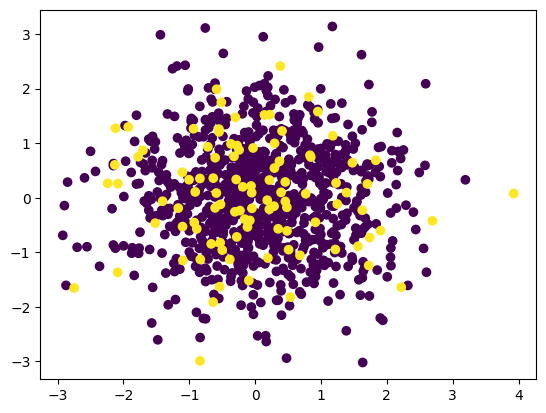

In [53]:
plt.scatter(df["feature_1"], df["feature_2"], c = df["target"]) # c is like hue 

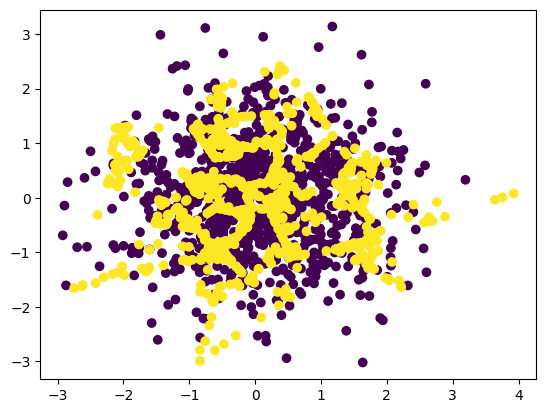

In [54]:
plt.scatter(oversample_df["feature_1"], oversample_df["feature_2"], c = oversample_df["target"]) # c is like hue 

In [56]:
# balanced data gives better results  while training data